In [6]:
from typing_extensions import TypedDict

# state definition for the application
class State(TypedDict):
    """State of the application."""
    graph_info:str

# playing node definition for the application
def start_play(state:State) -> State:
    """Start the application."""
    return {"graph_info":state["graph_info"]+"I am planning to play."}

# cricket and football playing node definitions for the application
def cricket_play(state:State) -> State:
    """Play cricket."""
    return {"graph_info":state["graph_info"]+"I am playing cricket."}

def football_play(state:State) -> State:
    """Play football."""
    return {"graph_info":state["graph_info"]+"I am playing football."}

In [7]:
import random
from typing import Literal

def random_play(state:State) -> Literal["cricket_play", "football_play"]:
    """Randomly choose to play cricket or football."""
    return random.choice(["cricket_play", "football_play"])

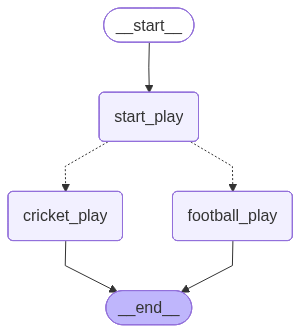

In [12]:
from langgraph.graph import StateGraph,START,END
from IPython.display import display, Image

# create the graph
graph = StateGraph(State)

# add nodes to the graph
graph.add_node("start_play", start_play)
graph.add_node("cricket_play", cricket_play)
graph.add_node("football_play", football_play)

# add edges to the graph
graph.add_edge(START, "start_play")
graph.add_conditional_edges("start_play", random_play)
graph.add_edge("cricket_play", END)
graph.add_edge("football_play", END)

# compile the graph
building_graph = graph.compile()
display(Image(building_graph.get_graph().draw_mermaid_png()))

In [16]:
building_graph.invoke({"graph_info":"my name is khaled. "})

{'graph_info': 'my name is khaled. I am planning to play.I am playing football.'}